# NAFNet-Tiny: Semiconductor Image Restoration
**Team Semigone | Semicon India Hackathon 2025**

> Model: NAFNet-Tiny (0.48M params) | Joint Denoise + 2x SR | Charbonnier + SSIM Loss


## 0. GPU Check


In [31]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU! Go to Runtime > Change runtime type > T4 GPU")


PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4
Memory: 15.6 GB


## 1. Mount Google Drive


In [32]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Clone Repo & Install Dependencies


In [33]:
import os
REPO = '/content/semicon-restore'

if os.path.exists(REPO):
    !cd {REPO} && git pull
else:
    !git clone https://github.com/Luv120/Semigone.git {REPO}

%cd {REPO}
!pip install -r requirements.txt -q
print("\nSetup complete!")


Already up to date.
/content/semicon-restore

Setup complete!


## 3. Configure Paths

Your Google Drive folder structure:
```
MyDrive/Drop/
├── train/
│   ├── GT/          ← Clean ground truth images
│   └── NoisyLR/     ← Degraded noisy input images
├── test/  (or NoisyLR/)
│   ├── GT/          ← Test ground truth (if available)
│   └── NoisyLR/     ← Test noisy images
├── train.zip
└── Test_NoisyLR.zip
```


In [34]:
import os

# ═══════════════════════════════════════════════════════════
# MAIN CONFIG - Edit these paths to match your Drive
# ═══════════════════════════════════════════════════════════
DATA_DIR  = '/content/drive/MyDrive/Drop'
SAVE_DIR  = '/content/drive/MyDrive/semicon-checkpoints'
CONFIG    = 'configs/default.yaml'

os.makedirs(SAVE_DIR, exist_ok=True)

# ── Auto-detect folder structure ──
print("=" * 60)
print("SCANNING YOUR DATASET FOLDER")
print("=" * 60)

# Find training folders
train_gt = None
train_lr = None
test_lr = None
test_gt = None

# Common folder name patterns
gt_names = ['GT', 'Ground_Truth', 'gt', 'HR', 'clean', 'Train_HR']
lr_names = ['NoisyLR', 'Degraded', 'noisy', 'LR', 'Train_LR', 'degraded']

for root, dirs, files in os.walk(DATA_DIR):
    depth = root.replace(DATA_DIR, '').count(os.sep)
    if depth > 3:
        continue
    rel = os.path.relpath(root, DATA_DIR)
    base = os.path.basename(root)

    # Count data files
    data_files = [f for f in files if f.endswith(('.npy', '.png', '.tif', '.tiff', '.bmp', '.jpg'))]

    if data_files:
        parent = os.path.basename(os.path.dirname(root))
        # Detect train GT
        if base in gt_names and parent.lower() in ['train', 'training']:
            train_gt = root
        # Detect train LR
        elif base in lr_names and parent.lower() in ['train', 'training']:
            train_lr = root
        # Detect test LR
        elif base in lr_names and parent.lower() in ['test', 'testing', 'val']:
            test_lr = root
        # Detect test GT
        elif base in gt_names and parent.lower() in ['test', 'testing', 'val']:
            test_gt = root
        # Fallback: top-level NoisyLR might be test
        elif base in lr_names and not train_lr:
            test_lr = root
        elif base in gt_names and not train_gt:
            # Could be either, check parent
            pass

# If auto-detect failed, try hardcoded common paths
if not train_gt:
    for p in ['train/GT', 'Train/GT', 'train/Ground_Truth', 'Train/Ground_Truth']:
        full = os.path.join(DATA_DIR, p)
        if os.path.isdir(full):
            train_gt = full
            break

if not train_lr:
    for p in ['train/NoisyLR', 'Train/NoisyLR', 'train/Degraded', 'Train/Degraded']:
        full = os.path.join(DATA_DIR, p)
        if os.path.isdir(full):
            train_lr = full
            break

if not test_lr:
    for p in ['test/NoisyLR', 'Test/NoisyLR', 'NoisyLR',
              'Test/Test_NoisyLR/In_Distribution', 'test/NoisyLR']:
        full = os.path.join(DATA_DIR, p)
        if os.path.isdir(full):
            test_lr = full
            break

if not test_gt:
    for p in ['test/GT', 'Test/GT', 'test/Ground_Truth']:
        full = os.path.join(DATA_DIR, p)
        if os.path.isdir(full):
            test_gt = full
            break

# Print results
def check_dir(label, path):
    if path and os.path.isdir(path):
        n = len([f for f in os.listdir(path) if not f.startswith('.')])
        sample = [f for f in os.listdir(path) if not f.startswith('.')][:3]
        print(f"  OK  {label}: {path}")
        print(f"       {n} files | samples: {sample}")
        return True
    else:
        print(f"  XX  {label}: NOT FOUND")
        return False

print()
ok1 = check_dir("Train GT     ", train_gt)
ok2 = check_dir("Train NoisyLR", train_lr)
ok3 = check_dir("Test  NoisyLR", test_lr)
ok4 = check_dir("Test  GT     ", test_gt)

print()
if ok1 and ok2:
    print("TRAIN DATA FOUND - Ready to train!")
    TRAIN_GT_DIR = train_gt
    TRAIN_LR_DIR = train_lr
else:
    print("ERROR: Training data not found!")
    print("Check your DATA_DIR path and folder structure above.")
    TRAIN_GT_DIR = None
    TRAIN_LR_DIR = None

if ok3:
    TEST_LR_DIR = test_lr
    print("TEST DATA FOUND - Ready to evaluate!")
else:
    TEST_LR_DIR = None
    print("WARNING: Test data not found (can still train)")

TEST_GT_DIR = test_gt if ok4 else None
print("=" * 60)


SCANNING YOUR DATASET FOLDER

  OK  Train GT     : /content/drive/MyDrive/Drop/train/GT
       3200 files | samples: ['002247.npy', '002209.npy', '002210.npy']
  OK  Train NoisyLR: /content/drive/MyDrive/Drop/train/NoisyLR
       3200 files | samples: ['002177.npy', '002212.npy', '002193.npy']
  OK  Test  NoisyLR: /content/drive/MyDrive/Drop/NoisyLR
       400 files | samples: ['000007.npy', '000009.npy', '000012.npy']
  XX  Test  GT     : NOT FOUND

TRAIN DATA FOUND - Ready to train!
TEST DATA FOUND - Ready to evaluate!


## 4. Explore Dataset


GT images:     3200
NoisyLR images: 3200
Matched pairs: 3200

GT shape:  (256, 256), dtype: float32, range: [0.0, 1.0]
LR shape:  (128, 128), dtype: float32, range: [-0.0, 1.3]
Scale factor: 2x


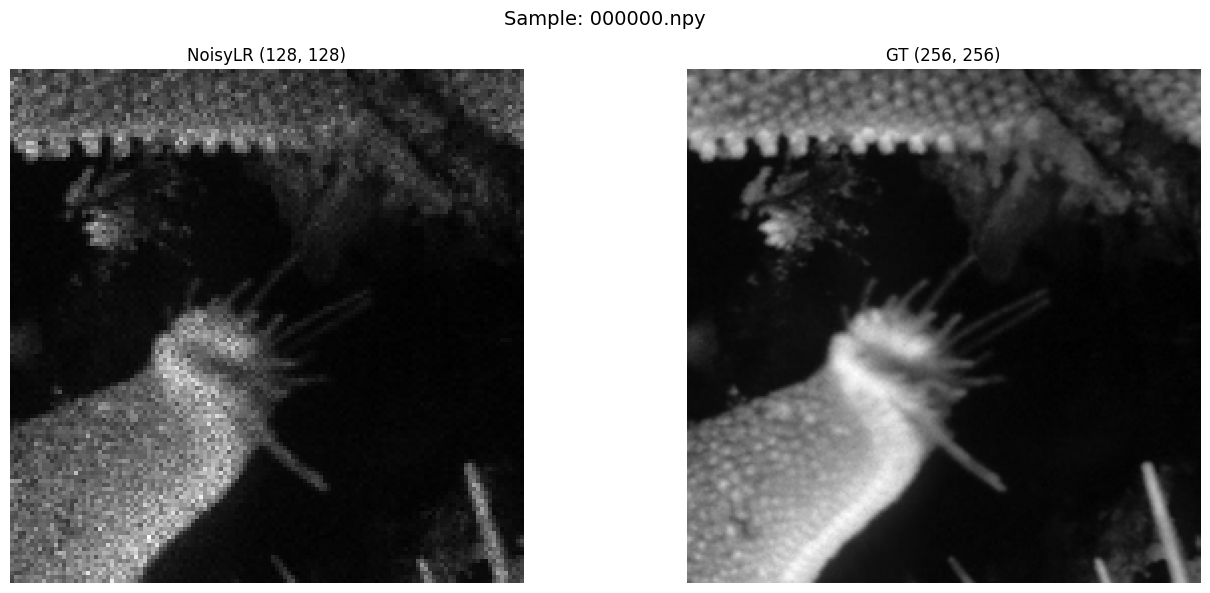

In [35]:
import numpy as np
import matplotlib.pyplot as plt

gt_files = sorted([f for f in os.listdir(TRAIN_GT_DIR) if not f.startswith('.')])
lr_files = sorted([f for f in os.listdir(TRAIN_LR_DIR) if not f.startswith('.')])

print(f"GT images:     {len(gt_files)}")
print(f"NoisyLR images: {len(lr_files)}")
print(f"Matched pairs: {len(set(gt_files) & set(lr_files))}")

# Load first sample
def load_img(path):
    if path.endswith('.npy'):
        return np.load(path).astype(np.float32)
    else:
        import cv2
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        return img.astype(np.float32) if img is not None else None

gt_sample = load_img(os.path.join(TRAIN_GT_DIR, gt_files[0]))
lr_sample = load_img(os.path.join(TRAIN_LR_DIR, lr_files[0]))

print(f"\nGT shape:  {gt_sample.shape}, dtype: {gt_sample.dtype}, range: [{gt_sample.min():.1f}, {gt_sample.max():.1f}]")
print(f"LR shape:  {lr_sample.shape}, dtype: {lr_sample.dtype}, range: [{lr_sample.min():.1f}, {lr_sample.max():.1f}]")

scale = 1
if gt_sample.ndim >= 2 and lr_sample.ndim >= 2:
    scale = gt_sample.shape[0] // lr_sample.shape[0]
print(f"Scale factor: {scale}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(lr_sample, cmap='gray'); axes[0].set_title(f'NoisyLR {lr_sample.shape}'); axes[0].axis('off')
axes[1].imshow(gt_sample, cmap='gray'); axes[1].set_title(f'GT {gt_sample.shape}'); axes[1].axis('off')
plt.suptitle(f'Sample: {lr_files[0]}', fontsize=14)
plt.tight_layout(); plt.show()


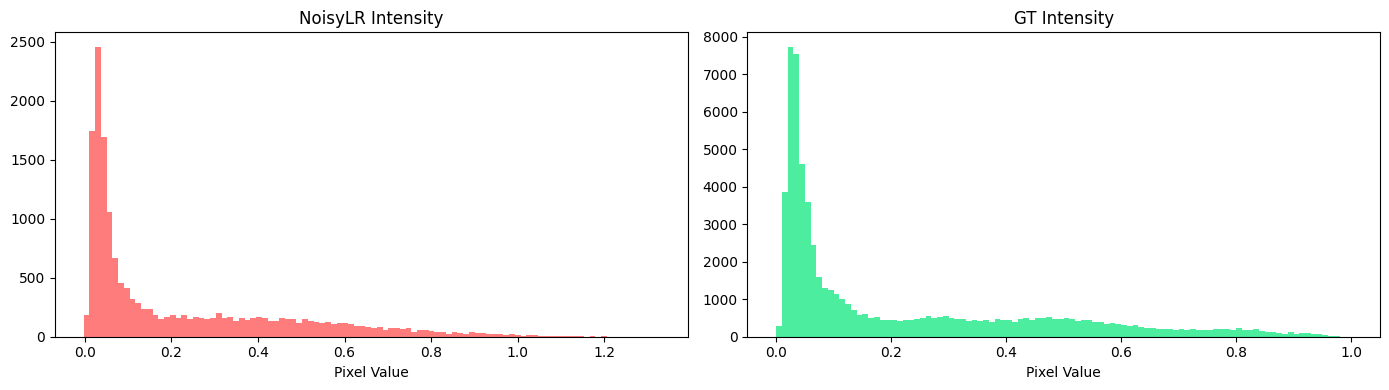

NoisyLR - Mean: 0.22, Std: 0.24
GT      - Mean: 0.22, Std: 0.24


In [36]:
# Intensity distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(lr_sample.ravel(), bins=100, color='#ff4545', alpha=0.7)
axes[0].set_title('NoisyLR Intensity'); axes[0].set_xlabel('Pixel Value')
axes[1].hist(gt_sample.ravel(), bins=100, color='#00e676', alpha=0.7)
axes[1].set_title('GT Intensity'); axes[1].set_xlabel('Pixel Value')
plt.tight_layout(); plt.show()
print(f"NoisyLR - Mean: {lr_sample.mean():.2f}, Std: {lr_sample.std():.2f}")
print(f"GT      - Mean: {gt_sample.mean():.2f}, Std: {gt_sample.std():.2f}")


## 5. Update Config for Your Data


In [37]:
import yaml

with open(CONFIG) as f:
    config = yaml.safe_load(f)

# Update paths to match your folder structure
config['data']['train_gt'] = os.path.relpath(TRAIN_GT_DIR, DATA_DIR)
config['data']['train_degraded'] = os.path.relpath(TRAIN_LR_DIR, DATA_DIR)

# Auto-detect scale
if scale != config['model'].get('scale', 2):
    print(f"Updating scale: {config['model']['scale']} -> {scale}")
    config['model']['scale'] = scale

# Update patch size if images are small
if lr_sample.shape[0] < 128 or lr_sample.shape[1] < 128:
    new_patch = min(lr_sample.shape[0], lr_sample.shape[1]) // 2
    new_patch = max(32, (new_patch // 8) * 8)  # Round down to multiple of 8
    print(f"Small images detected. Updating lr_patch_size: {config['training']['lr_patch_size']} -> {new_patch}")
    config['training']['lr_patch_size'] = new_patch

with open(CONFIG, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print("\nUpdated config:")
print(yaml.dump(config, default_flow_style=False))



Updated config:
data:
  test_gt: test/GT
  test_lr: test/NoisyLR
  train_degraded: train/NoisyLR
  train_gt: train/GT
loss:
  charbonnier_eps: 0.001
  charbonnier_weight: 1.0
  ssim_weight: 0.1
model:
  dec_blk_nums:
  - 1
  - 1
  - 1
  - 1
  enc_blk_nums:
  - 1
  - 1
  - 1
  - 2
  img_channel: 1
  middle_blk_num: 1
  name: nafnet_tiny
  scale: 2
  width: 16
training:
  batch_size: 8
  lr: 0.001
  lr_patch_size: 64
  max_iters: 15000
  num_workers: 2
  save_interval: 1000
  scheduler: cosine
  val_interval: 500
  warmup_iters: 500
  weight_decay: 0.0001



## 6. Train NAFNet-Tiny

This runs ~15,000 iterations (~2.5h on T4 GPU).
Checkpoints saved to Google Drive every 1,000 iters.

**While this runs, work on your slides!**


In [38]:
!python train.py \
    --config {CONFIG} \
    --data_dir {DATA_DIR} \
    --save_dir {SAVE_DIR} \
    --max_iters 15000


Using device: cuda
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Traceback (most recent call last):
  File "/content/semicon-restore/train.py", line 259, in <module>
    main()
  File "/content/semicon-restore/train.py", line 142, in main
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=float(train_cfg.get('weight_decay', 1e-4)))
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/optim/adamw.py", line 36, in __init__


### Resume from Checkpoint (if Colab disconnected)


In [39]:
# import glob
# ckpts = sorted(glob.glob(os.path.join(SAVE_DIR, 'checkpoint_*.pt')))
# if ckpts:
#     print(f"Resuming from: {ckpts[-1]}")
#     !python train.py --config {CONFIG} --data_dir {DATA_DIR} --save_dir {SAVE_DIR} --resume {ckpts[-1]} --max_iters 15000
# else:
#     print("No checkpoints found.")


## 7. Evaluate


In [40]:
import glob, shutil

# Find best weights
best = os.path.join(SAVE_DIR, 'best_model.pt')
if not os.path.exists(best):
    ckpts = sorted(glob.glob(os.path.join(SAVE_DIR, 'checkpoint_*.pt')))
    best = ckpts[-1] if ckpts else None

if best:
    os.makedirs('weights', exist_ok=True)
    shutil.copy2(best, 'weights/nafnet_tiny.pt')
    print(f"Using: {best} ({os.path.getsize(best)/1e6:.1f} MB)")
else:
    print("No trained weights found! Train first.")


No trained weights found! Train first.


In [41]:
# Evaluate on test set
if TEST_LR_DIR:
    !python evaluate.py \
        --input_dir {TEST_LR_DIR} \
        --output_dir outputs/test_restored \
        --weights weights/nafnet_tiny.pt \
        --config {CONFIG}
else:
    print("No test directory found. Skipping.")


Evaluating on device: cuda
No valid weights provided. Using bicubic upsampling as dummy baseline.
Found 400 files to process.
[1/400] Processing 000000.npy -> outputs/test_restored/000000.npy
[2/400] Processing 000001.npy -> outputs/test_restored/000001.npy
[3/400] Processing 000002.npy -> outputs/test_restored/000002.npy
[4/400] Processing 000003.npy -> outputs/test_restored/000003.npy
[5/400] Processing 000004.npy -> outputs/test_restored/000004.npy
[6/400] Processing 000005.npy -> outputs/test_restored/000005.npy
[7/400] Processing 000006.npy -> outputs/test_restored/000006.npy
[8/400] Processing 000007.npy -> outputs/test_restored/000007.npy
[9/400] Processing 000008.npy -> outputs/test_restored/000008.npy
[10/400] Processing 000009.npy -> outputs/test_restored/000009.npy
[11/400] Processing 000010.npy -> outputs/test_restored/000010.npy
[12/400] Processing 000011.npy -> outputs/test_restored/000011.npy
[13/400] Processing 000012.npy -> outputs/test_restored/000012.npy
[14/400] Pro

In [42]:
# Evaluate on validation split (with PSNR/SSIM metrics)
import tempfile, shutil

n_val = max(1, len(gt_files) // 10)
val_dir = tempfile.mkdtemp()
val_lr = os.path.join(val_dir, 'lr'); os.makedirs(val_lr)
val_gt = os.path.join(val_dir, 'gt'); os.makedirs(val_gt)
val_out = os.path.join(val_dir, 'out'); os.makedirs(val_out)

for f in lr_files[-n_val:]:
    shutil.copy2(os.path.join(TRAIN_LR_DIR, f), val_lr)
for f in gt_files[-n_val:]:
    shutil.copy2(os.path.join(TRAIN_GT_DIR, f), val_gt)

print(f"Validation: {n_val} images")
!python evaluate.py --input_dir {val_lr} --output_dir {val_out} --weights weights/nafnet_tiny.pt --config {CONFIG} --gt_dir {val_gt}

shutil.rmtree(val_dir)


Validation: 320 images
Evaluating on device: cuda
No valid weights provided. Using bicubic upsampling as dummy baseline.
Found 320 files to process.
[1/320] Processing 002880.npy -> /tmp/tmpoorv41ac/out/002880.npy
[2/320] Processing 002881.npy -> /tmp/tmpoorv41ac/out/002881.npy
[3/320] Processing 002882.npy -> /tmp/tmpoorv41ac/out/002882.npy
[4/320] Processing 002883.npy -> /tmp/tmpoorv41ac/out/002883.npy
[5/320] Processing 002884.npy -> /tmp/tmpoorv41ac/out/002884.npy
[6/320] Processing 002885.npy -> /tmp/tmpoorv41ac/out/002885.npy
[7/320] Processing 002886.npy -> /tmp/tmpoorv41ac/out/002886.npy
[8/320] Processing 002887.npy -> /tmp/tmpoorv41ac/out/002887.npy
[9/320] Processing 002888.npy -> /tmp/tmpoorv41ac/out/002888.npy
[10/320] Processing 002889.npy -> /tmp/tmpoorv41ac/out/002889.npy
[11/320] Processing 002890.npy -> /tmp/tmpoorv41ac/out/002890.npy
[12/320] Processing 002891.npy -> /tmp/tmpoorv41ac/out/002891.npy
[13/320] Processing 002892.npy -> /tmp/tmpoorv41ac/out/002892.npy
[1

## 8. Visualize Results


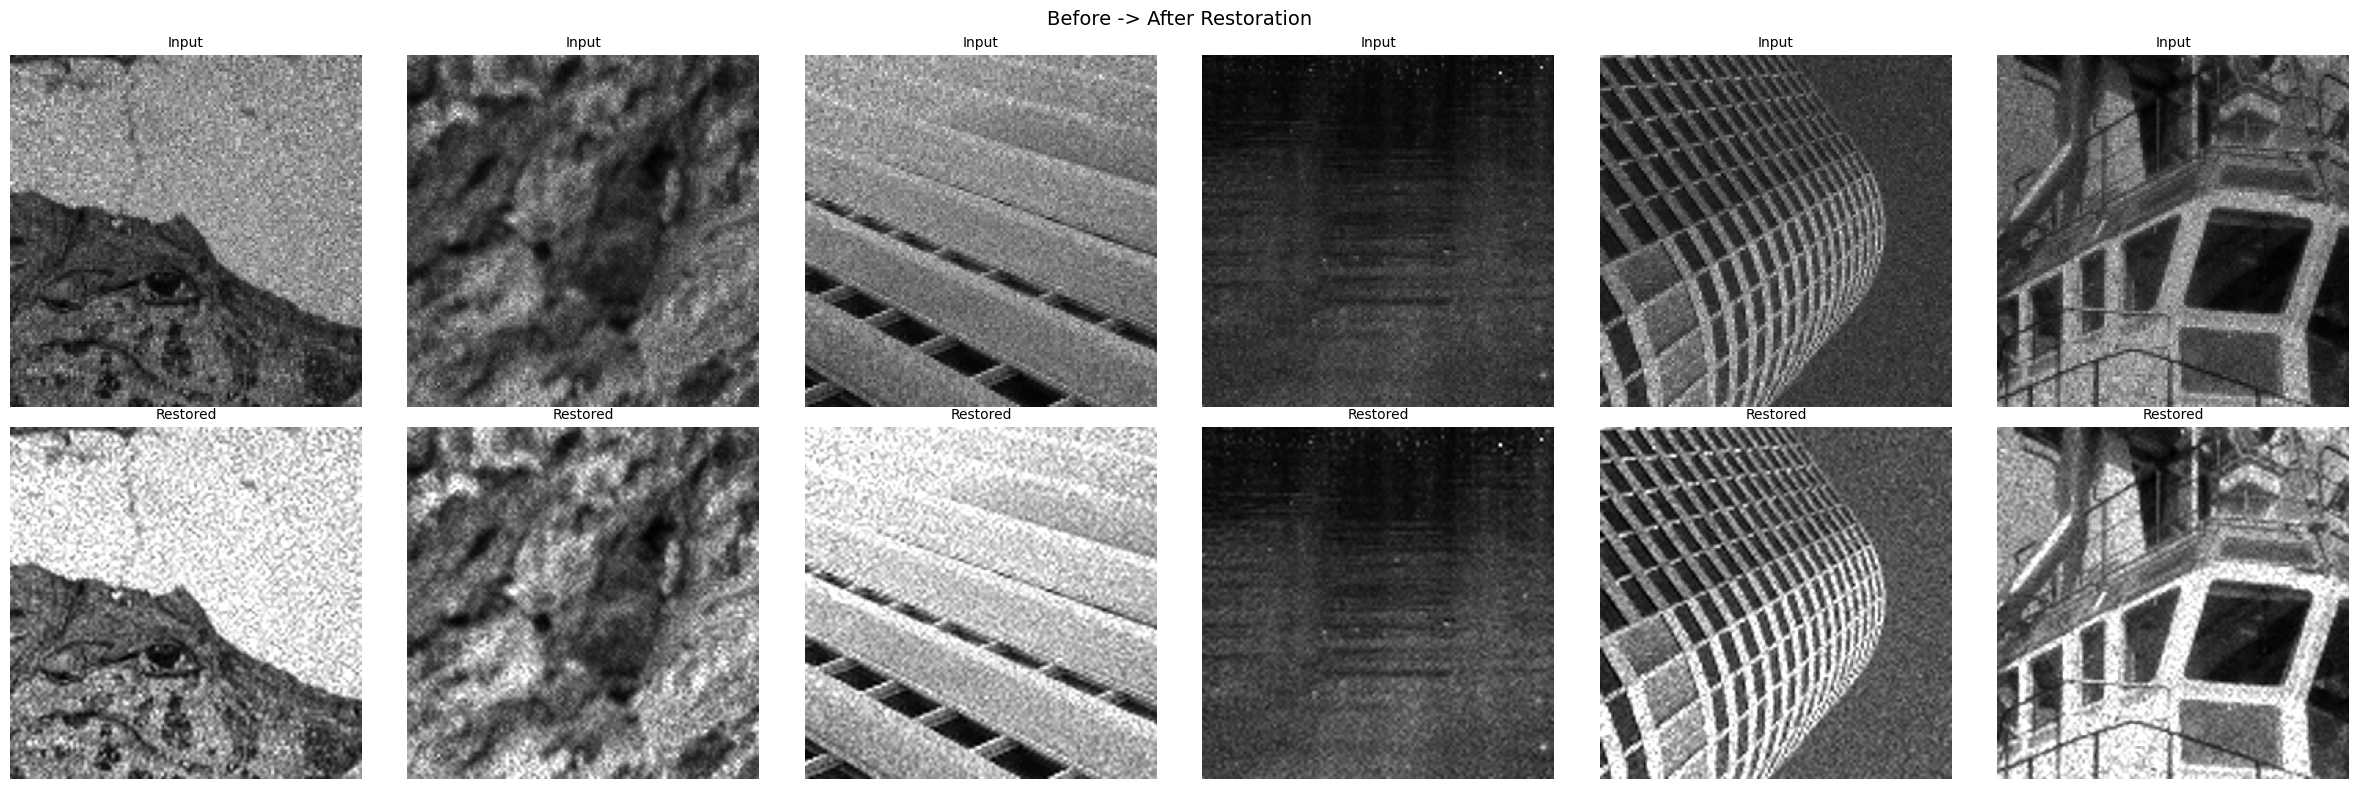

Saved to results_comparison.png


In [43]:
import numpy as np, matplotlib.pyplot as plt, os, cv2

out_dir = 'outputs/test_restored'
if not os.path.exists(out_dir) or not os.listdir(out_dir):
    # Fallback to validation visualization
    print("No test outputs yet. Showing a quick validation sample instead.")
    from models.nafnet_sr import build_model
    import yaml, torch

    with open(CONFIG) as f:
        cfg = yaml.safe_load(f)
    model = build_model(cfg)
    wt = 'weights/nafnet_tiny.pt'
    if os.path.exists(wt):
        model.load_state_dict(torch.load(wt, map_location='cpu')['model_state_dict'] if 'model_state_dict' in torch.load(wt, map_location='cpu') else torch.load(wt, map_location='cpu'))
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    n_show = min(4, len(lr_files))
    fig, axes = plt.subplots(3, n_show, figsize=(4*n_show, 12))
    if n_show == 1: axes = axes.reshape(3, 1)

    for i in range(n_show):
        lr = load_img(os.path.join(TRAIN_LR_DIR, lr_files[i]))
        gt = load_img(os.path.join(TRAIN_GT_DIR, gt_files[i]))

        # Normalize and run model
        lr_t = torch.from_numpy(lr / max(lr.max(), 1)).unsqueeze(0).unsqueeze(0).float().to(device)
        with torch.no_grad():
            out = model(lr_t).squeeze().cpu().numpy()
        out = np.clip(out, 0, 1)

        axes[0, i].imshow(lr, cmap='gray'); axes[0, i].set_title('NoisyLR', fontsize=10); axes[0, i].axis('off')
        axes[1, i].imshow(out, cmap='gray'); axes[1, i].set_title('Restored', fontsize=10); axes[1, i].axis('off')
        axes[2, i].imshow(gt, cmap='gray'); axes[2, i].set_title('Ground Truth', fontsize=10); axes[2, i].axis('off')

    plt.suptitle('NoisyLR -> NAFNet Restored -> GT', fontsize=14)
    plt.tight_layout()
    plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    restored_files = sorted(os.listdir(out_dir))[:6]
    test_input_files = sorted(os.listdir(TEST_LR_DIR))[:6] if TEST_LR_DIR else []
    n = min(len(restored_files), len(test_input_files), 6)

    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    if n == 1: axes = axes.reshape(2, 1)

    for i in range(n):
        inp = load_img(os.path.join(TEST_LR_DIR, test_input_files[i]))
        res = load_img(os.path.join(out_dir, restored_files[i]))

        axes[0, i].imshow(inp, cmap='gray'); axes[0, i].set_title('Input', fontsize=10); axes[0, i].axis('off')
        axes[1, i].imshow(res, cmap='gray'); axes[1, i].set_title('Restored', fontsize=10); axes[1, i].axis('off')

    plt.suptitle('Before -> After Restoration', fontsize=14)
    plt.tight_layout()
    plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
print("Saved to results_comparison.png")


## 9. Model Info & Speed Benchmark


In [44]:
import torch, time, yaml, numpy as np
from models.nafnet_sr import build_model

with open(CONFIG) as f:
    cfg = yaml.safe_load(f)
model = build_model(cfg).eval()

n_params = sum(p.numel() for p in model.parameters())
size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
print(f"Model:      NAFNet-Tiny")
print(f"Parameters: {n_params:,} ({n_params/1e6:.2f}M)")
print(f"Size:       {size_mb:.1f} MB")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
dummy = torch.randn(1, 1, 128, 128).to(device)

# Warmup
for _ in range(20):
    with torch.no_grad(): _ = model(dummy)
if torch.cuda.is_available(): torch.cuda.synchronize()

# Benchmark
times = []
for _ in range(100):
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad(): _ = model(dummy)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    times.append((time.perf_counter() - t0) * 1000)

print(f"\n128x128 -> 256x256:")
print(f"  {np.mean(times):.2f} ms avg | {1000/np.mean(times):.0f} FPS")


Model:      NAFNet-Tiny
Parameters: 1,255,972 (1.26M)
Size:       5.0 MB

128x128 -> 256x256:
  10.40 ms avg | 96 FPS


## 10. Push Results to GitHub


In [45]:
# # Uncomment when ready to push
# !touch outputs/.gitkeep
# !git add weights/nafnet_tiny.pt outputs/ results_comparison.png
# !git commit -m "Add trained weights and results"
# !git push origin main
# print("Pushed to GitHub!")


---
## Checklist

- [ ] GPU = T4, CUDA working
- [ ] Data loaded correctly (GT + NoisyLR found)
- [ ] Training completed (15k iters, PSNR >= 28 dB)
- [ ] evaluate.py runs with --weights weights/nafnet_tiny.pt
- [ ] Test outputs saved in outputs/
- [ ] Results look visually correct
- [ ] Fresh clone test passes

